# 01 — Exploratory Data Analysis

**Goal:** understand the AI4I 2020 dataset before modelling. What does a row represent, how rare are
failures, which failure modes exist, and which sensor signals differ between healthy and failing runs?

**Dataset:** [AI4I 2020 Predictive Maintenance Dataset](https://doi.org/10.24432/C5HS5C)
(Matzka, 2020, CC BY 4.0). It is a *synthetic* dataset that models a milling machine and was designed
to reflect real industrial predictive maintenance data.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pdm.config import FIGURES_DIR
from pdm.data import FAILURE_MODES, NUMERIC_FEATURES, TARGET, load_data

sns.set_theme(style="whitegrid", context="notebook")
LABELS = {0: "No failure", 1: "Failure"}
COLORS = {"No failure": "#8d99ae", "Failure": "#d1495b"}
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    fig.savefig(FIGURES_DIR / f"01_{name}.png", dpi=150, bbox_inches="tight")

## 1. Load and check the data

In [2]:
df = load_data()
df["status"] = df[TARGET].map(LABELS)
df.head()

,udi,product_id,type,air_temp_k,process_temp_k,rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,status
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,No failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,No failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,No failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,No failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,No failure


In [3]:
print(f"Rows: {len(df):,} | Columns: {df.shape[1] - 1}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.drop(columns='udi').duplicated().sum()}")
print(f"Unique product IDs: {df['product_id'].nunique():,}")

Rows: 10,000 | Columns: 14
Missing values: 0
Duplicate rows: 0
Unique product IDs: 10,000


The data is complete: no missing values and no duplicates. Every row has its own product ID, so each
row is an **independent snapshot** of one machining process, not a time series of one machine.
This makes the task a classification problem ("does this process end in a failure?"), not a
remaining-useful-life forecast.

## 2. Variables

| Column | Original name | Description | Role |
|---|---|---|---|
| `udi` | UDI | Row identifier | ID, not a feature |
| `product_id` | Product ID | Serial number, letter prefix = machine type | ID, not a feature |
| `type` | Type | Product quality variant: L (low, 60%), M (medium, 30%), H (high, 10%) | Feature |
| `air_temp_k` | Air temperature [K] | Ambient air temperature | Feature |
| `process_temp_k` | Process temperature [K] | Temperature of the machining process | Feature |
| `rpm` | Rotational speed [rpm] | Spindle speed | Feature |
| `torque_nm` | Torque [Nm] | Spindle torque | Feature |
| `tool_wear_min` | Tool wear [min] | Minutes the current tool has been in use | Feature |
| `machine_failure` | Machine failure | Process ended in a failure (0/1) | **Target** |
| `twf` | TWF | Tool wear failure | Failure mode label |
| `hdf` | HDF | Heat dissipation failure | Failure mode label |
| `pwf` | PWF | Power failure | Failure mode label |
| `osf` | OSF | Overstrain failure | Failure mode label |
| `rnf` | RNF | Random failure | Failure mode label |

The failure mode columns describe *why* a failure happened. They are only known after the fact, so
they must never be used as model inputs (that would be target leakage). We use them for analysis only.

## 3. Value ranges

In [4]:
df[NUMERIC_FEATURES].describe().T[["mean", "std", "min", "max"]].round(1)

,mean,std,min,max
air_temp_k,300.0,2.0,295.3,304.5
process_temp_k,310.0,1.5,305.7,313.8
rpm,1538.8,179.3,1168.0,2886.0
torque_nm,40.0,10.0,3.8,76.6
tool_wear_min,108.0,63.7,0.0,253.0


In [5]:
for col in ["air_temp_k", "process_temp_k"]:
    low, high = df[col].min() - 273.15, df[col].max() - 273.15
    print(f"{col:>15}: {low:.1f} to {high:.1f} °C")

     air_temp_k: 22.2 to 31.4 °C
 process_temp_k: 32.6 to 40.7 °C


All ranges are physically plausible:

- **Air temperature** 22–31 °C: normal workshop conditions.
- **Process temperature** 33–41 °C: consistently about 10 K above ambient, as expected.
- **Rotational speed** 1,168–2,886 rpm: typical spindle speeds for a milling machine.
- **Torque** 4–77 Nm: plausible range for a machine tool spindle.
- **Tool wear** 0–253 min: a tool is used for up to about 4 hours before replacement.

No values need to be removed or corrected.

## 4. Class imbalance

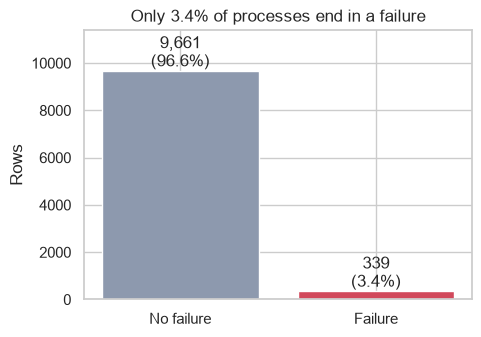

In [6]:
counts = df["status"].value_counts().reindex(LABELS.values())
failure_rate = df[TARGET].mean()

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(counts.index, counts.values, color=[COLORS[s] for s in counts.index])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({v / len(df):.1%})", ha="center", va="bottom")
ax.set_ylim(0, counts.max() * 1.18)
ax.set_ylabel("Rows")
ax.set_title(f"Only {failure_rate:.1%} of processes end in a failure")
save(fig, "class_balance")
plt.show()

Failures are rare, which is realistic for industrial data. Consequences for modelling:

- **Accuracy is useless:** always predicting "no failure" is already 96.6% accurate.
  We evaluate with **PR-AUC** (precision-recall) and F1 on the failure class instead.
- **Stratified cross-validation** keeps the failure share equal in every fold.
- Resampling to a 50/50 split is not required. Class weights and choosing the decision threshold
  deliberately (M5) are simpler and keep the predicted probabilities meaningful.

## 5. Failure modes

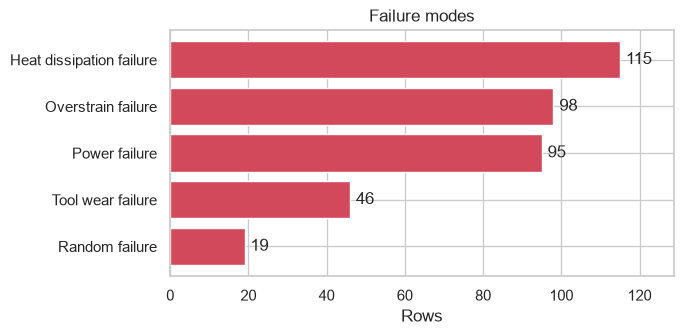

In [7]:
mode_counts = df[list(FAILURE_MODES)].sum().rename(index=FAILURE_MODES).sort_values()

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.barh(mode_counts.index, mode_counts.values, color=COLORS["Failure"])
for y, v in enumerate(mode_counts.values):
    ax.text(v + 1.5, y, str(v), va="center")
ax.set_xlim(0, mode_counts.max() * 1.12)
ax.set_xlabel("Rows")
ax.set_title("Failure modes")
save(fig, "failure_modes")
plt.show()

In [8]:
by_type = df.groupby("type", observed=True).agg(
    rows=(TARGET, "size"),
    failures=(TARGET, "sum"),
    failure_rate=(TARGET, "mean"),
    **{mode: (mode, "sum") for mode in FAILURE_MODES},
)
by_type.style.format({"failure_rate": "{:.2%}"})

,rows,failures,failure_rate,twf,hdf,pwf,osf,rnf
type,,,,,,,,
L,6000,235,3.92%,25,76,59,87,13
M,2997,83,2.77%,14,31,31,9,2
H,1003,21,2.09%,7,8,5,2,4


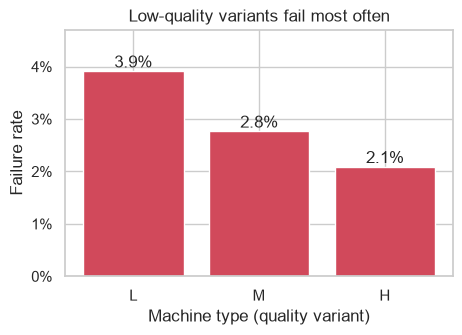

In [9]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(by_type.index.astype(str), by_type["failure_rate"], color=COLORS["Failure"])
for i, v in enumerate(by_type["failure_rate"]):
    ax.text(i, v, f"{v:.1%}", ha="center", va="bottom")
ax.set_ylim(0, by_type["failure_rate"].max() * 1.2)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Machine type (quality variant)")
ax.set_ylabel("Failure rate")
ax.set_title("Low-quality variants fail most often")
save(fig, "failure_rate_by_type")
plt.show()

- **Heat dissipation** is the most common failure mode, followed by overstrain and power failures.
- **Random failures** are very rare (19 rows).
- Type **L fails almost twice as often as H** (3.9% vs. 2.1%).
- **Overstrain** is almost exclusively an L problem (87 of 98 cases) even though L is only 60% of the
  data. This suggests the load a tool can withstand depends on the quality variant, so `type` should
  stay in the model.

## 6. Feature distributions: failure vs. no failure

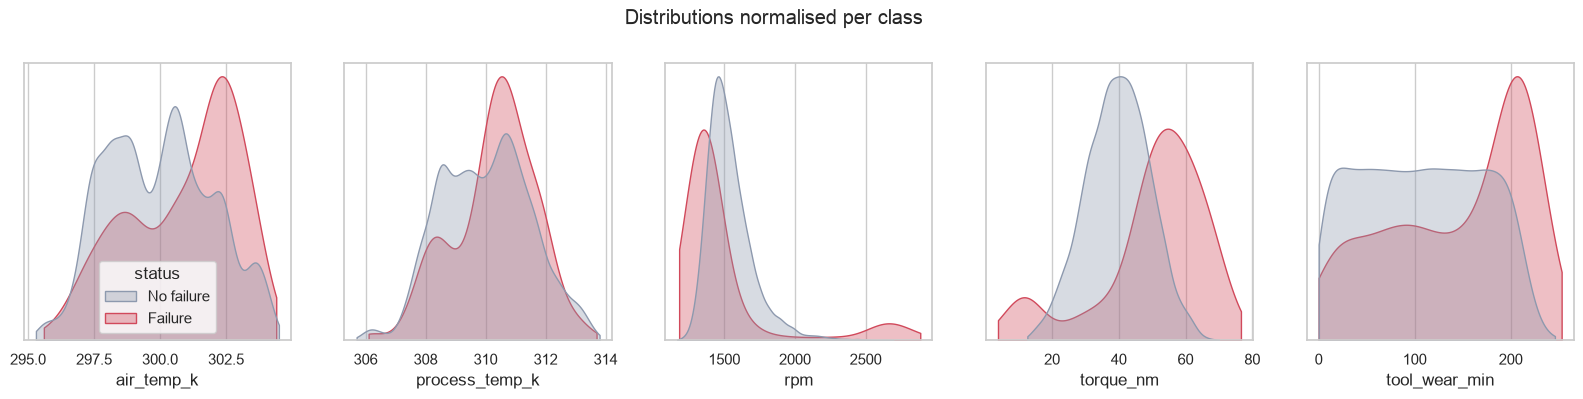

In [10]:
fig, axes = plt.subplots(1, len(NUMERIC_FEATURES), figsize=(20, 3.6))
for ax, col in zip(axes, NUMERIC_FEATURES, strict=True):
    sns.kdeplot(
        data=df,
        x=col,
        hue="status",
        hue_order=list(LABELS.values()),
        palette=COLORS,
        common_norm=False,
        fill=True,
        alpha=0.35,
        cut=0,
        ax=ax,
        legend=ax is axes[0],
    )
    ax.set_ylabel("")
    ax.set_yticks([])
fig.suptitle("Distributions normalised per class", y=1.03)
save(fig, "feature_distributions")
plt.show()

Densities are normalised per class, so the shapes are comparable despite the imbalance.

- **Torque:** failures shift clearly towards high torque, with a smaller group at very low torque.
- **Rotational speed:** failures appear at both ends, at low speed and at very high speed.
- **Tool wear:** failures accumulate between about 200 and 240 minutes.
- **Air temperature:** failures lean towards warmer ambient conditions.
- **Process temperature:** hardly any difference.

The distributions overlap heavily. No single sensor separates the classes, so we should look at
combinations of features.

## 7. Feature interactions

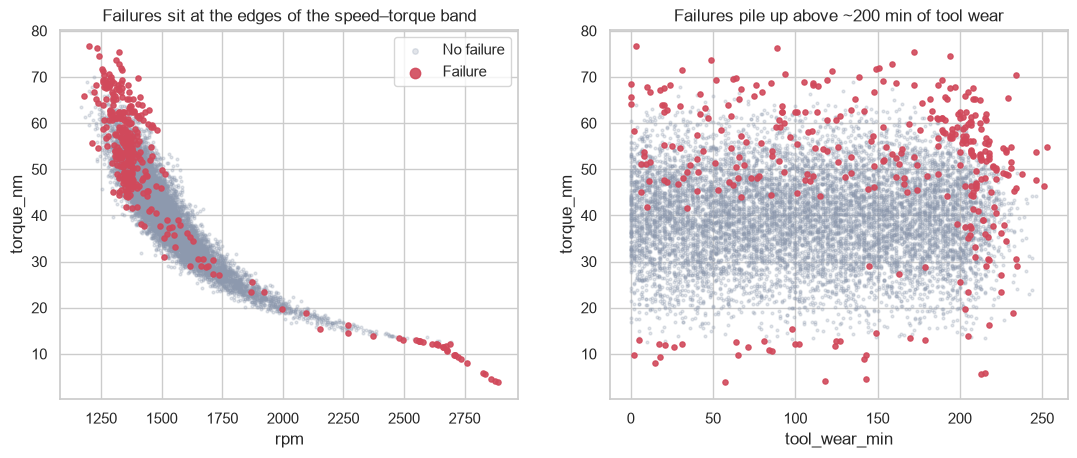

In [11]:
ok, fail = df[df[TARGET] == 0], df[df[TARGET] == 1]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
pairs = [("rpm", "torque_nm"), ("tool_wear_min", "torque_nm")]
for ax, (x, y) in zip(axes, pairs, strict=True):
    ax.scatter(ok[x], ok[y], s=4, alpha=0.25, color=COLORS["No failure"], label="No failure")
    ax.scatter(fail[x], fail[y], s=14, alpha=0.9, color=COLORS["Failure"], label="Failure")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
axes[0].set_title("Failures sit at the edges of the speed–torque band")
axes[1].set_title("Failures pile up above ~200 min of tool wear")
axes[0].legend(loc="upper right", markerscale=2)
save(fig, "interactions")
plt.show()

These plots show much clearer structure than the single distributions:

- **Speed vs. torque:** speed and torque are tightly coupled. Failures cluster at the two ends of that
  band (high torque at low speed, low torque at very high speed). Torque and speed together determine
  the mechanical power, which suggests the model needs to capture their *combination*.
- **Tool wear vs. torque:** below about 200 minutes of wear, failures occur mostly at high torque.
  Above it, they appear across almost the whole torque range. Wear and load seem to act together,
  so their combination may matter more than either value on its own.

We will test these observations with explainability in M3 and physics-based features in M4.

## 8. Correlations

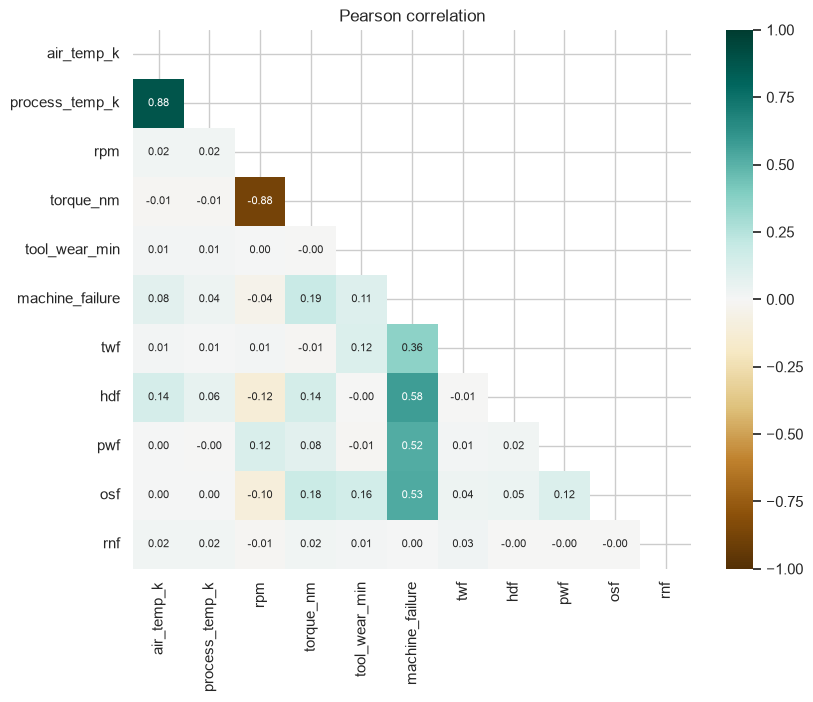

In [12]:
corr = df.drop(columns=["udi", "product_id", "type", "status"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="BrBG",
    center=0,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 8},
    ax=ax,
)
ax.set_title("Pearson correlation")
save(fig, "correlation")
plt.show()

In [13]:
corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(2)

hdf               0.58
osf               0.53
pwf               0.52
twf               0.36
torque_nm         0.19
tool_wear_min     0.11
air_temp_k        0.08
rpm              -0.04
process_temp_k    0.04
rnf               0.00
Name: machine_failure, dtype: float64

- **Air and process temperature** are strongly correlated (0.88), as are **speed and torque** (−0.88).
  The simulation couples these pairs.
- The **linear** correlation of every sensor with `machine_failure` is weak (at most about 0.19 for
  torque). Failures are driven by non-linear conditions and interactions, not by a single sensor rising
  steadily. A linear model will struggle, while tree-based models should do better (M2).
- The failure mode labels correlate strongly with the target, which is expected: they are sub-labels of
  it, not features.

## 9. Label consistency

In [14]:
any_mode = df[list(FAILURE_MODES)].any(axis=1)
pd.crosstab(
    df["status"],
    any_mode.map({False: "No mode flagged", True: "At least one mode flagged"}),
    rownames=["Target"],
    colnames=["Failure mode labels"],
)

Failure mode labels,At least one mode flagged,No mode flagged
Target,,
Failure,330,9
No failure,18,9643


In [15]:
failure_without_mode = df[(df[TARGET] == 1) & ~any_mode]
mode_without_failure = df[(df[TARGET] == 0) & any_mode]
multiple_modes = df[df[list(FAILURE_MODES)].sum(axis=1) > 1]

print(f"Failures without any failure mode: {len(failure_without_mode)}")
print(f"Failure mode flagged but no failure: {len(mode_without_failure)}")
print(f"  of which random failures (RNF): {mode_without_failure['rnf'].sum()}")
print(f"Rows with more than one failure mode: {len(multiple_modes)}")

Failures without any failure mode: 9
Failure mode flagged but no failure: 18
  of which random failures (RNF): 18
Rows with more than one failure mode: 24


The labels are not perfectly consistent:

- **9 failures have no failure mode.** Nothing in the data explains them, so they act as label noise.
- **18 rows have a failure mode but no failure**, and all of them are random failures (RNF).
  Only 1 of the 19 RNF rows counts as a machine failure, so random failures barely affect the target.
- **24 rows have more than one failure mode**, so the modes are not mutually exclusive.

**Decision:** we keep `machine_failure` as given, since it is the label a maintenance team would care
about. The inconsistencies limit the best achievable score, and we will quantify this ceiling in M4.

## 10. Key takeaways

1. The data is clean and complete, and every row is an independent process snapshot.
2. Failures are rare (3.4%), so we use PR-AUC, stratified CV and deliberate threshold selection.
3. There are five failure modes. Heat dissipation, overstrain and power failures dominate. Type L
   fails most, especially through overstrain.
4. Single sensors separate the classes poorly, but **combinations** (speed × torque, tool wear ×
   torque) show clear failure regions.
5. Linear correlations with the target are weak, so non-linear models are needed.
6. Some label noise (9 unexplained failures) caps the achievable performance.

**Next (M2):** baseline models on the raw sensor features.